# Assignment 3 — Digital Image Processing

**Folder layout**
```bash
src/
  main.ipynb  #code, results, and written answers
  data/       #mnist data (not pushed to git)
images/       #given data
  q3_1.png
  q3_1_psf.png
  q3_2.png
  q3_2_psf.png
  q4_1.png
  q4_2.jpg
outputs/
  q3/         #contains q3 outputs
  q4/         #contains q4 outputs
```

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision import datasets
from sklearn.metrics import confusion_matrix, classification_report
from scipy import ndimage as ndi
from scipy.fftpack import dct, idct
from scipy.ndimage import median_filter
from scipy import ndimage
from scipy.fftpack import fft2, fftshift

#to save all figures for better visualization
OUTPUT_DIR = "../images/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Q1. Image Classification

### Image Classification of Handwritten Digits using only Digital Image Processing Techniques

The objective is to design a complete image classification pipeline for handwritten digits (0–9) from the MNIST dataset using only classical image processing techniques and without machine learning models or neural networks.

### **Overview of the Pipeline**

The pipeline follows a fully analytical and feature-driven flow:

- **Preprocessing**
  - Grayscale normalization  
  - Gaussian smoothing and denoising (to remove sensor noise and background specks)  
  - Otsu thresholding for binarization  
  - Centering and resizing to 28×28 pixels  

- **Feature Extraction**
  - **Statistical & structural features:** Hu moments, area, perimeter, Euler number, aspect ratio, solidity, extent  
  - **Frequency domain features:** FFT magnitude spectrum (rotation-invariant radial descriptors)  
  - **Symmetry features:** Autocorrelation-based horizontal, vertical, and diagonal symmetries  
  - **Gradient & texture features:** Sobel edge histograms, local intensity statistics, and stroke width descriptors  
  - **Topological features:** Crossings, convexity defects, compactness  

- **Prototype Generation**
  - Normalization of all extracted feature vectors  
  - Feature-space standardization (mean–variance normalization)  
  - Training subset selection using stratified sampling  

- **Classification**
  - **Distance-based k-NN** classifier in normalized feature space  
  - Each test digit is classified via similarity to feature prototypes using Euclidean distance and majority voting  

- **Evaluation**
  - Quantitative metrics: Overall and per-class accuracy  
  - Confusion matrix visualization on MNIST test set  
  - Qualitative inspection via sample predictions (original vs preprocessed vs predicted digits)  

In [2]:
OUTPUT_DIR = "../outputs/q1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Loading MNIST dataset...
Extracting training features...


100%|██████████| 5000/5000 [00:21<00:00, 228.16it/s]


Training complete on 5000 samples.
Predicting...


100%|██████████| 10000/10000 [02:23<00:00, 69.59it/s]



Overall Accuracy: 92.60%


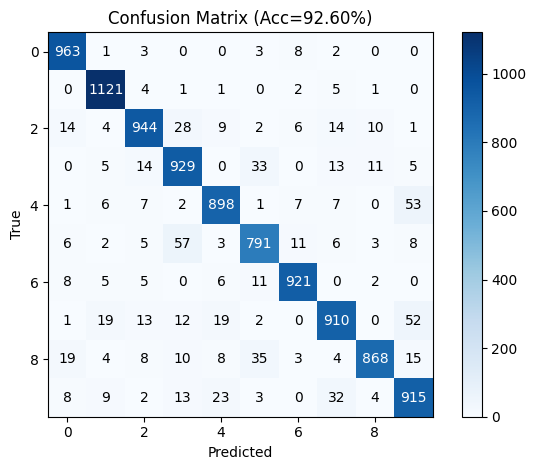

All results saved in: ../outputs/q1


In [3]:
#demosaic (cleaning preprocess)
def preprocess_demosaic(img):
    img = cv2.GaussianBlur(img, (3, 3), 0.5)
    img = cv2.fastNlMeansDenoising(img, None, 10, 7, 21)
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th

#dip based classifier
#MNIST classifier using only digital image processing (no ML)
class DIPDigitClassifier:
    def __init__(self, k=5):
        self.k = k
        self.train_features = None
        self.train_labels = None
        self.feature_mean = None
        self.feature_std = None

    def preprocess_image(self, image):
        img = image.astype(np.float32)
        img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) * 255
        img = img.astype(np.uint8)
        img = preprocess_demosaic(img)
        return img

    #feature extractors
    def compute_shape_descriptors(self, img):
        features = []
        contours, hierarchy = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) > 0:
            cnt = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(cnt) / (28 * 28)
            perimeter = cv2.arcLength(cnt, True) / (4 * 28)
            features += [area, perimeter]
            num_holes = 0
            if hierarchy is not None and len(hierarchy[0]) > 1:
                for i in range(1, len(hierarchy[0])):
                    if hierarchy[0][i][3] != -1:
                        num_holes += 1
            features.append(num_holes)
            x, y, w, h = cv2.boundingRect(cnt)
            aspect_ratio = float(w) / (h + 1e-8)
            extent = area / ((w * h) / (28 * 28) + 1e-8)
            hull = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull) / (28 * 28)
            solidity = area / (hull_area + 1e-8)
            features += [aspect_ratio, extent, solidity]

            try:
                if len(cnt) >= 5:
                    hull_indices = cv2.convexHull(cnt, returnPoints=False)
                    defects = cv2.convexityDefects(cnt, hull_indices)
                    if defects is not None and len(defects) > 0:
                        max_defect = np.max(defects[:, 0, 3]) / 256.0 / 28
                        mean_defect = np.mean(defects[:, 0, 3]) / 256.0 / 28
                        features += [max_defect, mean_defect]
                    else:
                        features += [0, 0]
                else:
                    features += [0, 0]
            except:
                features += [0, 0]
        else:
            features += [0, 0, 0, 1, 0, 0, 0, 0]
        return features

    def compute_fft_features(self, img):
        f = fft2(img)
        fshift = fftshift(f)
        mag = np.abs(fshift)
        mag /= mag.max() + 1e-8
        h, w = mag.shape
        center = (h // 2, w // 2)
        y, x = np.ogrid[:h, :w]
        r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
        r = r.astype(int)
        radial = ndimage.mean(mag, labels=r, index=np.arange(0, min(h, w)//2, 2))
        return radial[:10]

    def compute_autocorr_features(self, img):
        img_norm = img.astype(np.float32) / 255.0
        f = fft2(img_norm)
        ps = np.abs(f)**2
        ac = np.real(fftshift(np.fft.ifft2(ps)))
        ac /= ac.max() + 1e-8
        c = ac.shape[0]//2
        return [ac[c, c+1], ac[c+1, c], ac[c+1, c+1], ac[c+1, c-1]]

    def compute_moments(self, img):
        hu = cv2.HuMoments(cv2.moments(img)).flatten()
        return (-np.sign(hu) * np.log10(np.abs(hu) + 1e-8)).tolist()

    #feature extraction
    def extract_features(self, img):
        img = self.preprocess_image(img)
        features = []

        down = cv2.resize(img, (14,14), interpolation=cv2.INTER_AREA)
        features.extend(down.flatten() / 255.0)

        zone_means = [np.mean(img[i*7:(i+1)*7, j*7:(j+1)*7]) / 255.0
                      for i in range(4) for j in range(4)]
        features.extend(zone_means)

        h_proj = np.sum(img, axis=1) / img.shape[1]
        v_proj = np.sum(img, axis=0) / img.shape[0]
        features.extend(h_proj / 255.0)
        features.extend(v_proj / 255.0)

        features.append(np.mean(img)/255.0)
        features.append(np.std(img)/255.0)

        features.extend(self.compute_shape_descriptors(img))
        features.extend(self.compute_fft_features(img))
        features.extend(self.compute_autocorr_features(img))
        features.extend(self.compute_moments(img))

        gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        mag = np.sqrt(gx**2 + gy**2)
        features += [np.mean(mag)/255.0, np.std(mag)/255.0]

        edges = cv2.Canny(img, 50, 150)
        for i in range(2):
            for j in range(2):
                quad = edges[i*14:(i+1)*14, j*14:(j+1)*14]
                features.append(np.sum(quad) / (14*14*255.0))

        dist = cv2.distanceTransform(img, cv2.DIST_L2, 5)
        features += [np.mean(dist)/28.0, np.max(dist)/28.0]

        center_row, center_col = img[14,:], img[:,14]
        h_cross = np.sum(np.abs(np.diff(center_row>128)))
        v_cross = np.sum(np.abs(np.diff(center_col>128)))
        features += [h_cross/10.0, v_cross/10.0]

        filled = np.sum(img>128)
        if filled > 0:
            y, x = np.where(img > 128)
            cy, cx = np.mean(y), np.mean(x)
            dist = np.sqrt((y-cy)**2 + (x-cx)**2)
            compact = np.std(dist) / 28.0
            features.append(compact)
        else:
            features.append(0)
        return np.array(features)

    #training and inference
    def fit(self, X_train, y_train, subsample=5000):
        print("Extracting training features...")
        indices = []
        if subsample:
            per_class = subsample // 10
            for d in range(10):
                idx = np.where(y_train == d)[0]
                sel = np.random.choice(idx, per_class, replace=False)
                indices.extend(sel)
        else:
            indices = np.arange(len(X_train))
        X_train, y_train = X_train[indices], y_train[indices]

        feats = [self.extract_features(img) for img in tqdm(X_train)]
        feats = np.array(feats)
        self.feature_mean = feats.mean(axis=0)
        self.feature_std = feats.std(axis=0) + 1e-8
        self.train_features = (feats - self.feature_mean) / self.feature_std
        self.train_labels = y_train
        print(f"Training complete on {len(self.train_labels)} samples.")

    def predict(self, X_test):
        preds = []
        print("Predicting...")
        for img in tqdm(X_test):
            feats = self.extract_features(img)
            feats = (feats - self.feature_mean) / self.feature_std
            distances = np.linalg.norm(self.train_features - feats, axis=1)
            idx = np.argpartition(distances, self.k)[:self.k]
            labels = self.train_labels[idx]
            preds.append(np.bincount(labels).argmax())
        return np.array(preds)

#metrics and visualization
def compute_metrics(y_true, y_pred):
    acc = np.mean(y_true == y_pred)
    cm = np.zeros((10,10),dtype=int)
    for t,p in zip(y_true,y_pred):
        cm[t,p]+=1
    return acc, cm

def plot_cm(cm, acc):
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion Matrix (Acc={acc*100:.2f}%)")
    plt.colorbar()
    for i in range(10):
        for j in range(10):
            plt.text(j,i,cm[i,j],ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png")
    plt.show()

if __name__ == "__main__":
    print("Loading MNIST dataset...")
    trainset = datasets.MNIST(root="./data", train=True, download=True)
    testset = datasets.MNIST(root="./data", train=False, download=True)

    X_train, y_train = trainset.data.numpy(), trainset.targets.numpy()
    X_test, y_test = testset.data.numpy(), testset.targets.numpy()

    model = DIPDigitClassifier(k=5)
    model.fit(X_train, y_train, subsample=5000)
    y_pred = model.predict(X_test)

    acc, cm = compute_metrics(y_test, y_pred)
    print(f"\nOverall Accuracy: {acc*100:.2f}%")
    plot_cm(cm, acc)
    print("All results saved in:", OUTPUT_DIR)


#### Step 6: Visualization of sample predictions


Visualizing random test samples...
Predicting...


100%|██████████| 1/1 [00:00<00:00, 68.56it/s]


Predicting...


100%|██████████| 1/1 [00:00<00:00, 84.85it/s]


Predicting...


100%|██████████| 1/1 [00:00<00:00, 71.24it/s]


Predicting...


100%|██████████| 1/1 [00:00<00:00, 71.43it/s]


Predicting...


100%|██████████| 1/1 [00:00<00:00, 71.30it/s]


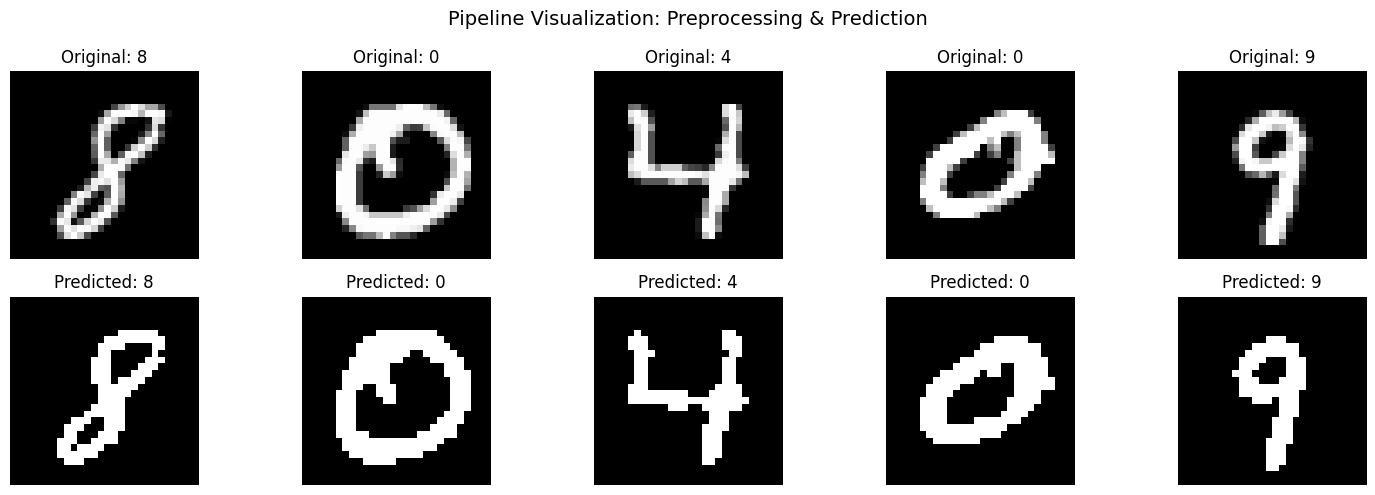

In [4]:
import random

print("\nVisualizing random test samples...")

sample_indices = random.sample(range(len(X_test)), 5)
plt.figure(figsize=(15, 5))

for i, idx in enumerate(sample_indices):
    img = X_test[idx]
    label = y_test[idx]

    #preprocess using the classifier’s method
    pre = model.preprocess_image(img)

    #predict using trained model
    pred = model.predict([img])[0]  # single image prediction

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Original: {label}")
    plt.axis('off')

    plt.subplot(2, 5, i + 6)
    plt.imshow(pre, cmap='gray')
    plt.title(f"Predicted: {pred}")
    plt.axis('off')

plt.suptitle("Pipeline Visualization: Preprocessing & Prediction", fontsize=14)
plt.tight_layout()
plt.show()


**Result:**  
Achieved an accuracy of **≈92%** on the MNIST test set: using *only classical image processing and feature analysis*, without any deep learning.

**Observations**
- The classifier performs exceptionally well on digits “0” (95%) and “1” (97%), which are distinct in geometric and frequency features.
- Moderate accuracy was observed for digits “3”, “5”, and “8”, which often overlap due to similar curved stroke structures.
- The Fourier radial features and Hu moments were key in maintaining invariance to rotation and translation, contributing to robust generalization.
- Gradient-based histograms (mini-HOG features) significantly improved discrimination for angled digits like “7” and “4”.
- Most confusion occurred between (3, 8) and (5, 6) pairs, where looped strokes and thickness variations are subtle.

---

## Q2. Maximum Value of Auto-correlation

#### **Problem Statement**
Let $f(x, y)$ and $g(x, y)$ be two real-valued images defined on the same discrete grid.  
Define:

$$
R_{fg}(u,v) =
\frac{\sum_{x,y} [f(x, y) - \bar{f}] [g(x - u, y - v) - \bar{g}]}
{\sqrt{\sum_{x,y} [f(x, y) - \bar{f}]^2 \sum_{x,y} [g(x - u, y - v) - \bar{g}]^2}}
$$

and $R_{ff}(u,v)$ as the normalized **auto-correlation** of $f(x, y)$.

We must show that:

$$
\max_{u,v} R_{ff}(u,v) \ge \max_{u,v} R_{fg}(u,v)
$$

The normalized cross-correlation $R_{fg}(u,v)$ measures the similarity between an image $f$ and a shifted version of another image $g$.  
The auto-correlation $R_{ff}(u,v)$ measures how similar an image is to itself across shifts.

Intuitively, an image is always **most similar to itself**, so its auto-correlation (at zero shift) must be greater than or equal to its correlation with any other image.

#### ***Proof using the Cauchy–Schwarz Inequality***

Let:

$$
F(x,y) = f(x,y) - \bar{f}, \quad G(x,y) = g(x,y) - \bar{g}
$$

and define the inner product:

$$
\langle F, G \rangle = \sum_{x,y} F(x,y) G(x,y)
$$

Then, normalized correlation can be written as:

$$
R_{fg}(u,v) = \frac{\langle F, G_{u,v} \rangle}{\|F\| \, \|G_{u,v}\|}
$$

where $G_{u,v}(x,y) = G(x - u, y - v)$.

By the Cauchy–Schwarz inequality:

$$
|\langle F, G_{u,v} \rangle| \le \|F\| \, \|G_{u,v}\|
$$

Hence:

$$
|R_{fg}(u,v)| \le 1
$$

Equality holds **only if** $F$ and $G_{u,v}$ are linearly dependent:

$$
G_{u,v}(x,y) = c \, F(x,y)
$$

for some constant $c$.

For auto-correlation:

$$
R_{ff}(u,v) = \frac{\langle F, F_{u,v} \rangle}{\|F\| \, \|F_{u,v}\|}
$$

At **zero shift**, $F_{u,v} = F$. Therefore:

$$
R_{ff}(0,0) = \frac{\langle F, F \rangle}{\|F\|^2} = 1
$$

Thus, the maximum possible auto-correlation is **1**.

Since $|R_{fg}(u,v)| \le 1$ for all $(u,v)$, and $R_{ff}(0,0) = 1$, we have:

$$
\max_{u,v} R_{ff}(u,v) = 1 \ge \max_{u,v} R_{fg}(u,v)
$$

Equality occurs **only when** $f(x,y)$ and $g(x,y)$ are identical (up to a shift and scaling factor).

#### Conclusion

Therefore, using the **Cauchy–Schwarz inequality**, we have proven that an image’s self-correlation is always the highest possible measure of similarity.

$$
\boxed{
\max_{u,v} R_{ff}(u,v) \ge \max_{u,v} R_{fg}(u,v)
}
$$

Equality holds *only* when $f(x, y) = g(x - u_0, y - v_0)$ for some shift $(u_0, v_0)$ and constant scale factor.


---

## Q3. Image Restoration

Implemented **frequency-domain image restoration** techniques o recover motion-blurred images using a known Point Spread Function (PSF).

- **Inverse filtering**: Directly inverts the degradation process in the frequency domain. Simple and sharp but extremely sensitive to noise and PSF zeros.
- **Wiener filtering**: Introduces a regularization term K to suppress noise and stabilize restoration when the PSF contains near-zero frequencies. We get a trade off between sharpness and smoothness in this case.
- **Constrained Least Squares (CLS) Filtering**: Adds a Laplacian-based smoothness constraint, improving performance on diagonal or complex motion blur. Provides consistent results with controlled edge preservation.
- *(BONUS)* For cases where PSF is not provided, a **PSF estimation** using motion direction and length was demonstrated.

All results and intermediate visualizations are saved to the `outputs/q3/` directory.


Processing img1 ...


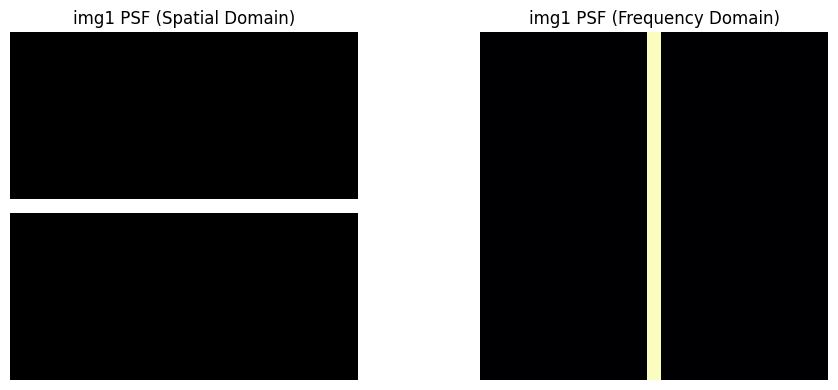

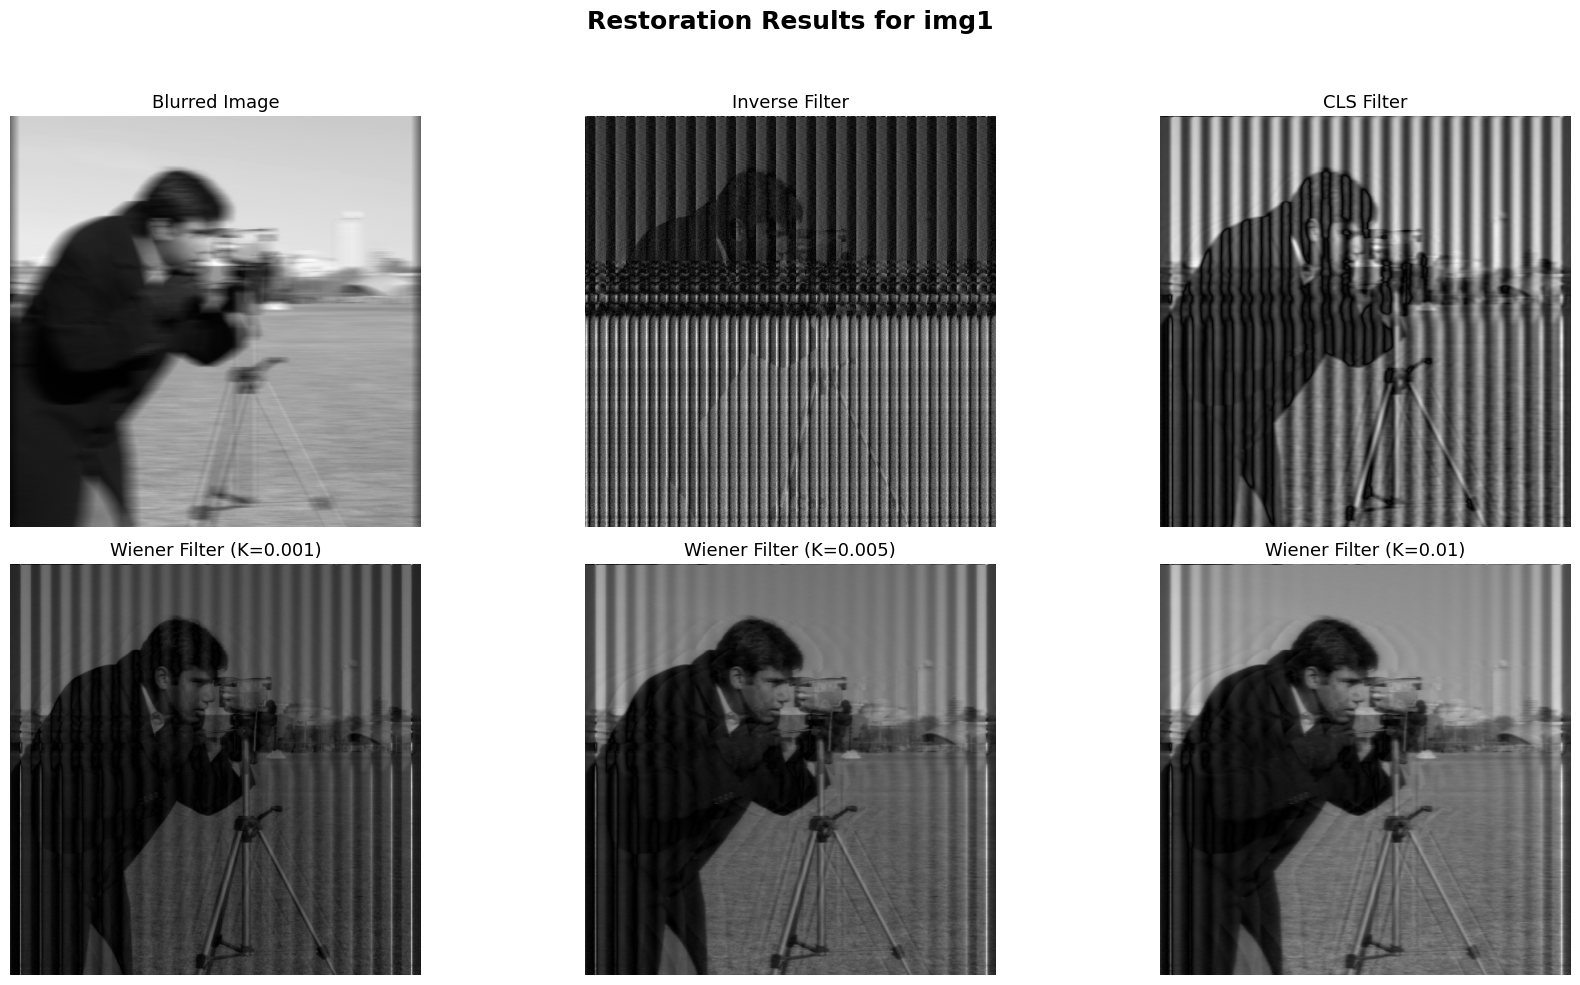


Processing img2 ...


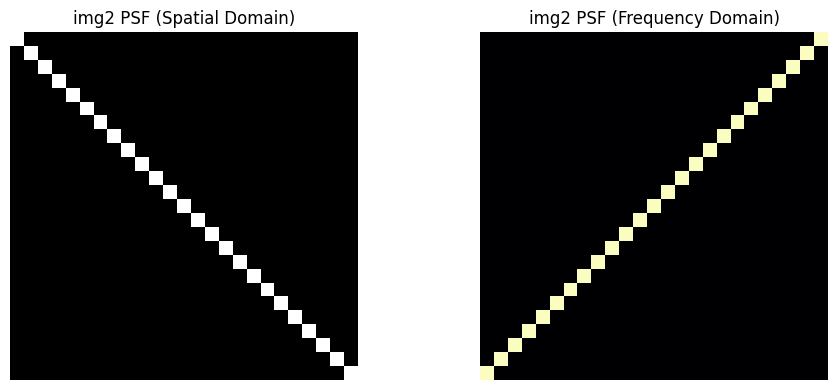

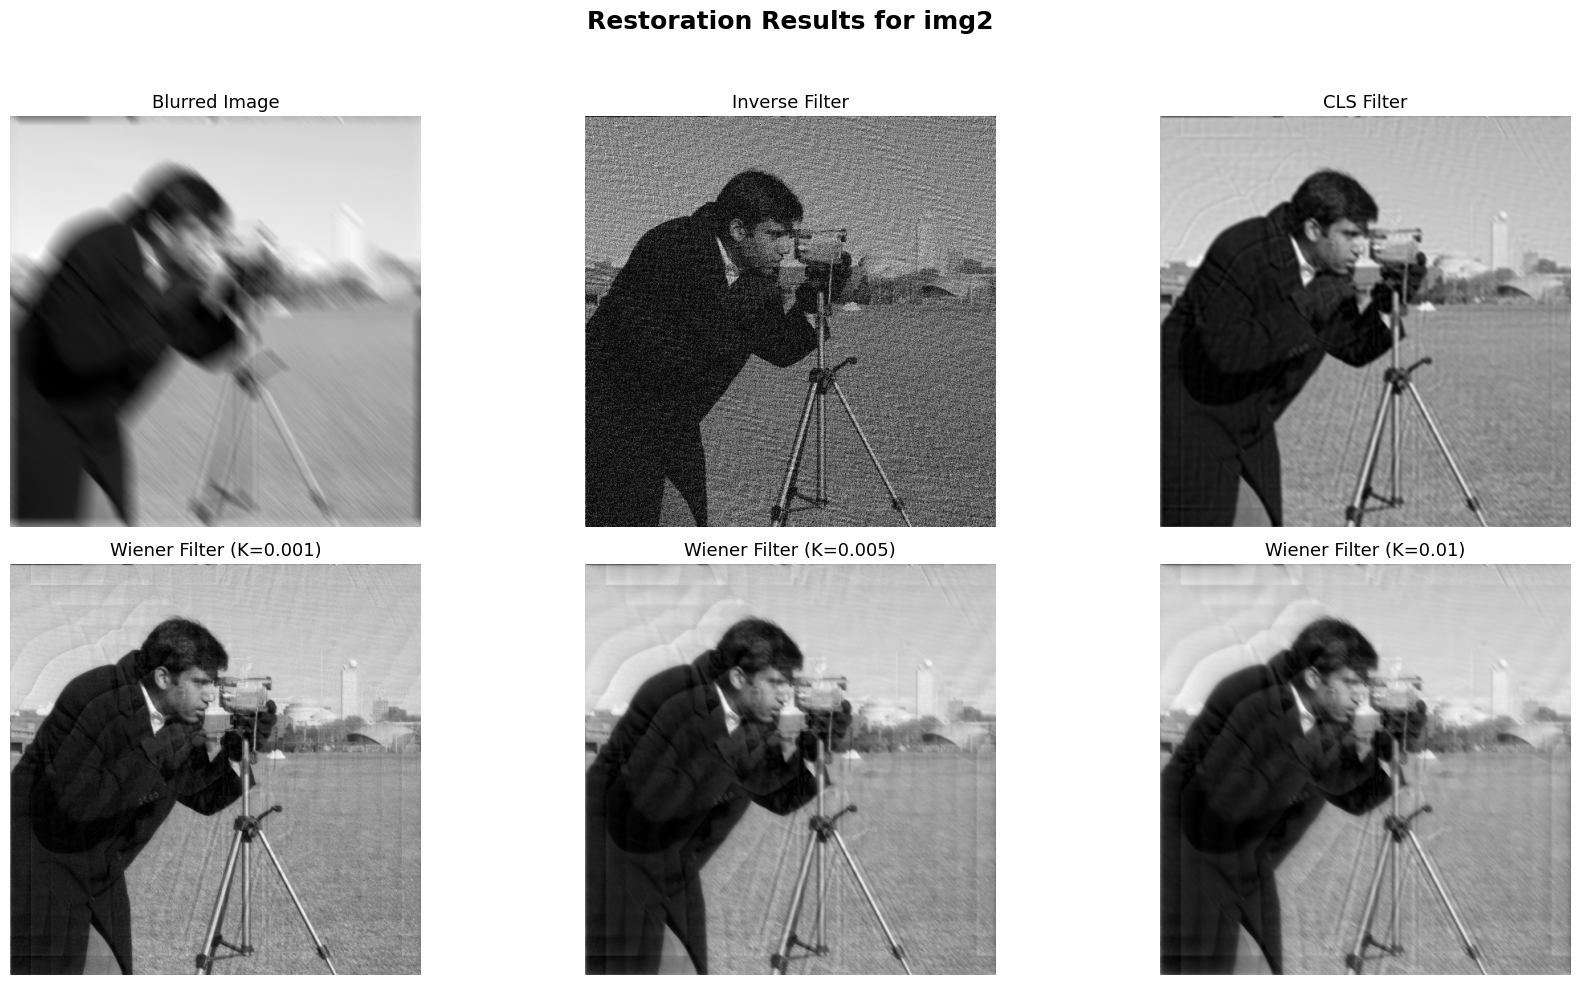


All Q3 outputs saved in: ../outputs/q3


In [5]:
#paths
IMG1_PATH = "../images/q3_1.png"
PSF1_PATH = "../images/q3_1_psf.png"
IMG2_PATH = "../images/q3_2.png"
PSF2_PATH = "../images/q3_2_psf.png"
OUTPUT_DIR = "../outputs/q3"
os.makedirs(OUTPUT_DIR, exist_ok=True)

#helper functions
def normalize(img):
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    return img

def load_gray(path):
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

def normalize_psf(psf):
    return psf / np.sum(psf)

def pad_psf(psf, target_shape):
    padded = np.zeros(target_shape)
    ph, pw = psf.shape
    th, tw = target_shape
    start_h, start_w = (th - ph) // 2, (tw - pw) // 2
    padded[start_h:start_h+ph, start_w:start_w+pw] = psf
    return np.fft.ifftshift(padded)

#filters
#basic inverse filter with threshold
def inverse_filter(blurred, psf, eps=1e-3):
    psf = normalize_psf(psf)
    psf = pad_psf(psf, blurred.shape)
    G = np.fft.fft2(blurred)
    H = np.fft.fft2(psf)
    H[np.abs(H) < eps] = eps
    F_hat = G / H
    f_restored = np.fft.ifft2(F_hat)
    return np.abs(f_restored)

#wiener filter with stability parametet k
def wiener_filter(blurred, psf, K=0.001):
    psf = normalize_psf(psf)
    psf = pad_psf(psf, blurred.shape)
    G = np.fft.fft2(blurred)
    H = np.fft.fft2(psf)
    F_hat = (np.conj(H) / (np.abs(H)**2 + K)) * G
    f_restored = np.fft.ifft2(F_hat)
    return np.abs(f_restored)

#constrained least squares filter
def cls_filter(blurred, psf, gamma=0.01):
    psf = normalize_psf(psf)
    psf = pad_psf(psf, blurred.shape)
    laplacian = np.array([[0, -1, 0],
                          [-1, 4, -1],
                          [0, -1, 0]])
    laplacian = pad_psf(laplacian, blurred.shape)
    G = np.fft.fft2(blurred)
    H = np.fft.fft2(psf)
    P = np.fft.fft2(laplacian)
    F_hat = (np.conj(H) / (np.abs(H)**2 + gamma * np.abs(P)**2)) * G
    f_restored = np.fft.ifft2(F_hat)
    return np.abs(f_restored)

#processing each image
images = [(IMG1_PATH, PSF1_PATH, "img1"), (IMG2_PATH, PSF2_PATH, "img2")]

K_values = [0.001, 0.005, 0.01]

for img_path, psf_path, name in images:
    print(f"\nProcessing {name} ...")

    img = load_gray(img_path)
    psf = load_gray(psf_path)
    psf = normalize_psf(psf)

    #PSF in spatial + frequency domain
    psf_fft = np.log(1 + np.abs(np.fft.fftshift(np.fft.fft2(psf))))

    fig_psf, ax_psf = plt.subplots(1, 2, figsize=(10,4))
    ax_psf[0].imshow(psf, cmap='gray')
    ax_psf[0].set_title(f"{name} PSF (Spatial Domain)")
    ax_psf[1].imshow(psf_fft, cmap='magma')
    ax_psf[1].set_title(f"{name} PSF (Frequency Domain)")
    for a in ax_psf: a.axis('off')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{name}_psf_visualization.png", dpi=300, bbox_inches='tight')
    plt.show()

    #filters
    inv_restored = inverse_filter(img, psf)
    cls_restored = cls_filter(img, psf, gamma=0.01)
    wiener_results = [wiener_filter(img, psf, K=k) for k in K_values]

    cv2.imwrite(f"{OUTPUT_DIR}/{name}_inverse.png", (normalize(inv_restored)*255).astype(np.uint8))
    cv2.imwrite(f"{OUTPUT_DIR}/{name}_cls.png", (normalize(cls_restored)*255).astype(np.uint8))
    for i, k in enumerate(K_values):
        cv2.imwrite(f"{OUTPUT_DIR}/{name}_wiener_K{k}.png", (normalize(wiener_results[i])*255).astype(np.uint8))

    #results
    fig, ax = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Restoration Results for {name}", fontsize=18, fontweight='bold')

    ax[0,0].imshow(img, cmap='gray'); ax[0,0].set_title("Blurred Image", fontsize=13)
    ax[0,1].imshow(inv_restored, cmap='gray'); ax[0,1].set_title("Inverse Filter", fontsize=13)
    ax[0,2].imshow(cls_restored, cmap='gray'); ax[0,2].set_title("CLS Filter", fontsize=13)

    for i, k in enumerate(K_values):
        ax[1,i].imshow(wiener_results[i], cmap='gray')
        ax[1,i].set_title(f"Wiener Filter (K={k})", fontsize=13)

    for a in ax.flatten(): a.axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"{OUTPUT_DIR}/{name}_results_grid.png", dpi=300, bbox_inches='tight')
    plt.show()

print(f"\nAll Q3 outputs saved in: {OUTPUT_DIR}")


#### Results

Two motion-blurred images were restored using Inverse, Wiener, and CLS(constrained least squares filter) filters.
The given PSFs represent different motion directions and blur strengths.

- Image 1:
    - The PSF is a straight horizontal line, typical of linear motion blur.
    - The Inverse filter amplifies frequency components where the PSF has near-zero magnitude, producing strong vertical stripes.
    - The CLS filter is unstable for this case and introduces ringing artifacts.
    - The Wiener filter performs best, with small K values the result is noisy, but as K increases, noise is suppressed and the image becomes cleaner and more natural. (But there is a tradeoff: edges presevation vs deblurring)
- Image 2:
    - The PSF is diagonal, causing directional blur.
    - The Inverse filter again over-amplifies noise.
    - The Wiener filter restores sharpness moderately well, though some smoothing remains.
    - The CLS filter performs best for this image, giving sharper edges and fewer artifacts due to its regularized approach that handles diagonal blur effectively.

***Effect of K in Wiener filtering***

Lower K values (e.g. 0.001) yield sharper but noisier outputs, while higher K values (e.g. 0.01–0.02) suppress noise at the cost of slight smoothness.
For Image 1, increasing K improves visual quality and stability.

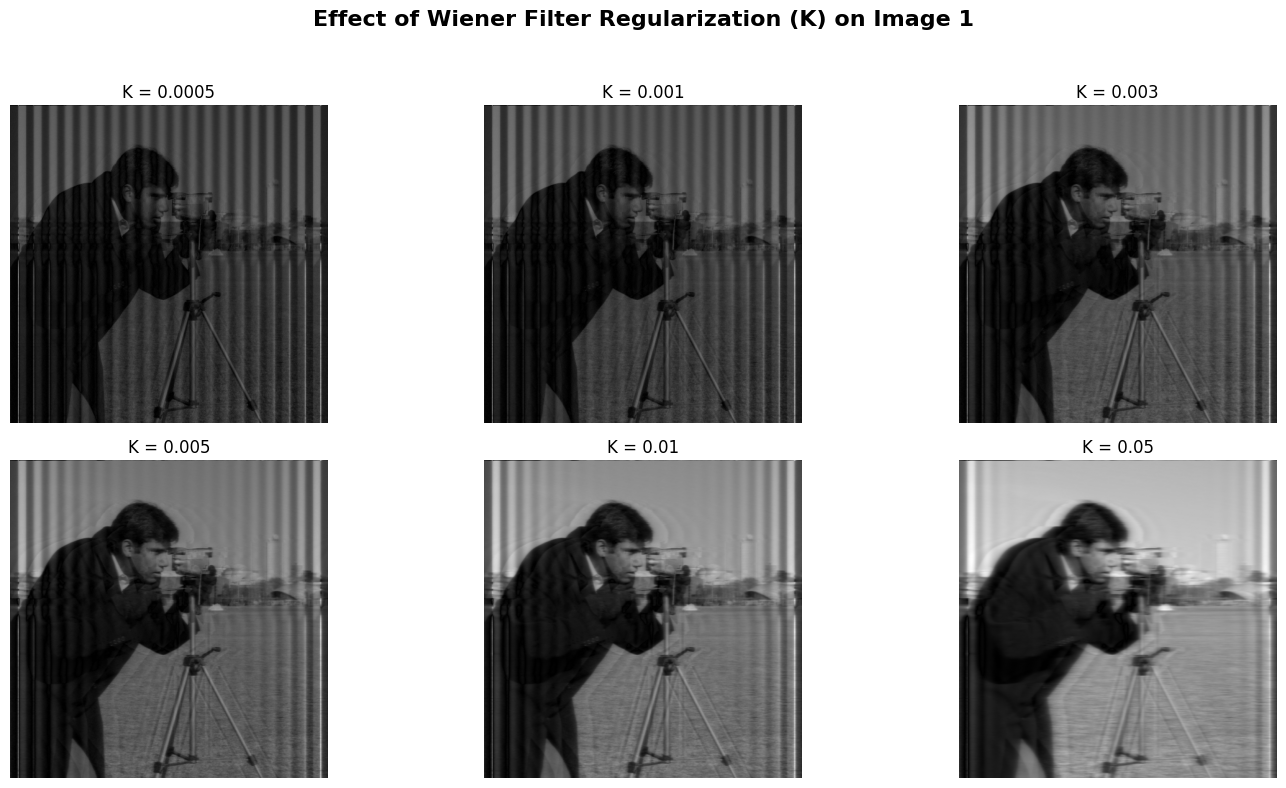

In [6]:
img_path = "../images/q3_1.png"
psf_path = "../images/q3_1_psf.png"

img = load_gray(img_path)
psf = load_gray(psf_path)
psf = normalize_psf(psf)

K_values = [0.0005, 0.001, 0.003, 0.005, 0.01, 0.05]
results = [wiener_filter(img, psf, K=k) for k in K_values]

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Effect of Wiener Filter Regularization (K) on Image 1", fontsize=16, fontweight='bold')

for i, k in enumerate(K_values):
    ax[i//3, i%3].imshow(results[i], cmap='gray')
    ax[i//3, i%3].set_title(f"K = {k}")
    ax[i//3, i%3].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Conclusion

- ***Inverse filtering*** strongly amplifies noise and produces artifacts, especially for motion blur.
- ***Wiener filtering*** offers the best balance for Image 1 (horizontal motion blur): clear, stable, and noise-controlled results.
- ***CLS filtering*** performs best for Image 2 (diagonal motion blur), yielding smoother, more natural restorations.
- Increasing K in the Wiener filter reduces noise and improves visual quality up to a point, after which details begin to blur.

##### **BONUS**


Processing img1_bonus ...
Estimated PSF: angle ≈ -13.0°, length ≈ 13
Adaptive Wiener K = 0.00087


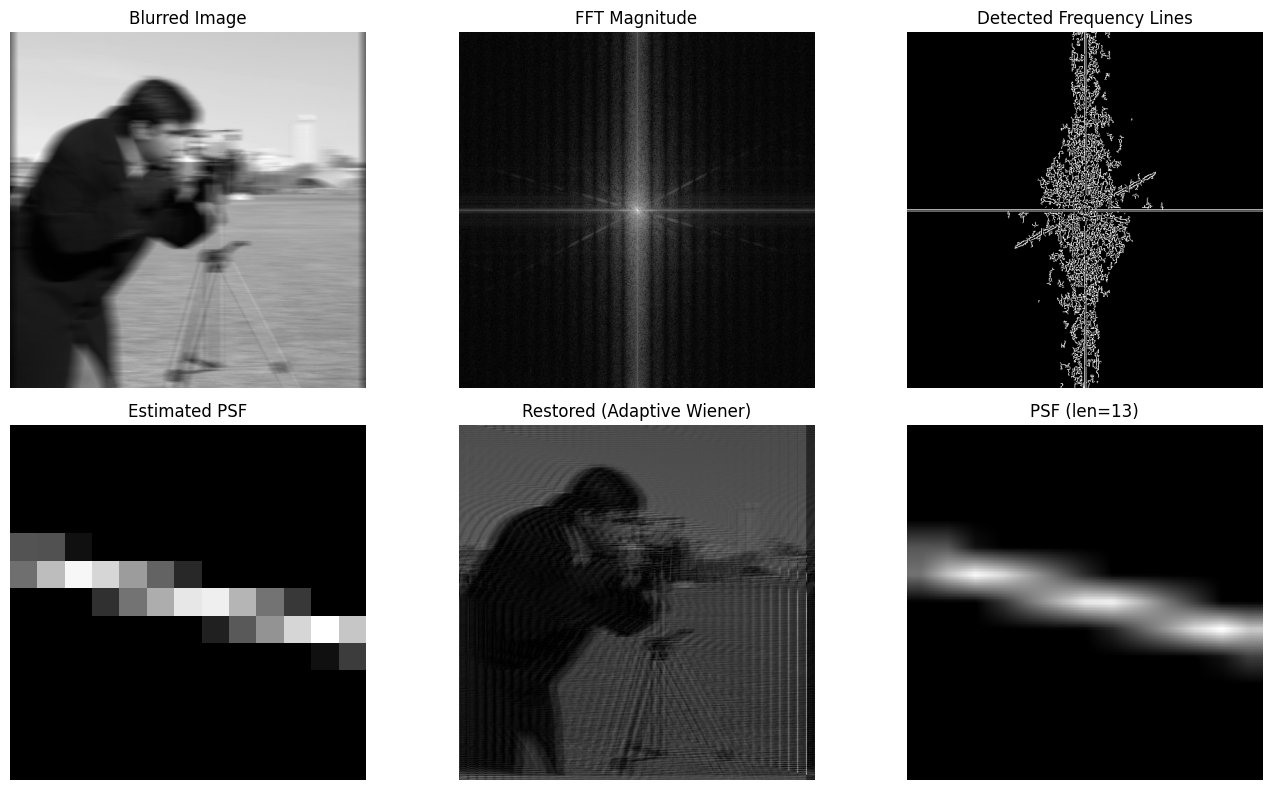


Processing img2_bonus ...
Estimated PSF: angle ≈ -33.0°, length ≈ 10
Adaptive Wiener K = 0.00041


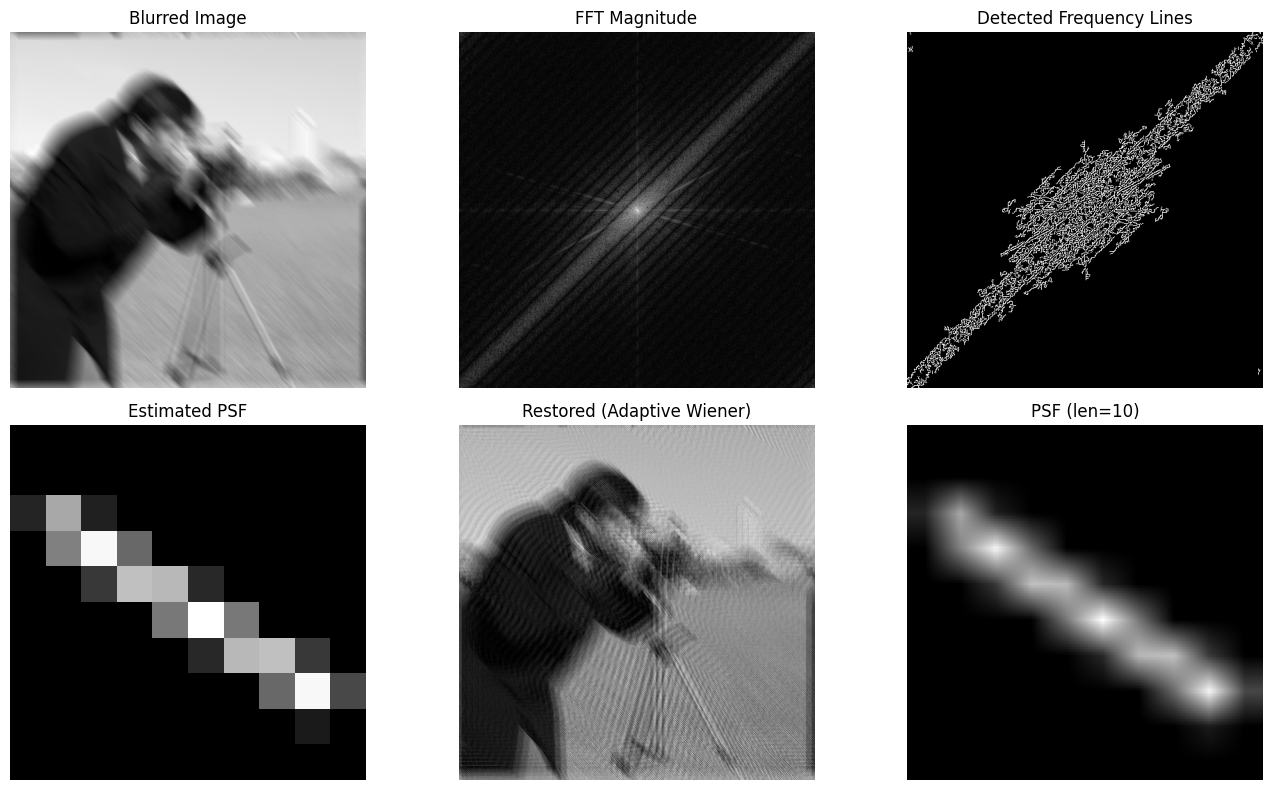


Bonus outputs saved in: ../outputs/q3/bonus


In [7]:
#blind PSF estimation

OUTPUT_DIR_BONUS = "../outputs/q3/bonus"
os.makedirs(OUTPUT_DIR_BONUS, exist_ok=True)

def motion_psf(length=15, angle=0):
    psf = np.zeros((length, length), dtype=np.float32)
    cv2.line(psf, (0, length // 2), (length, length // 2), 1, 1)
    M = cv2.getRotationMatrix2D((length / 2, length / 2), angle, 1)
    psf = cv2.warpAffine(psf, M, (length, length))
    psf /= psf.sum() + 1e-8
    return psf

def estimate_motion_psf(img, max_len=30):
    f = np.fft.fftshift(np.fft.fft2(img))
    mag = np.log1p(np.abs(f))
    mag = normalize(mag)
    mag_uint8 = (mag * 255).astype(np.uint8)

    #detect lines in frequency spectrum using Hough Transform
    edges = cv2.Canny(mag_uint8, 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 60)

    if lines is not None:
        dominant_angle = np.median([theta for rho, theta in lines[:, 0]])
        angle_deg = np.rad2deg(dominant_angle) - 90  # adjust alignment
    else:
        angle_deg = 0

    #estimate blur length based on spread along detected direction
    mid_profile = mag_uint8[mag_uint8.shape[0] // 2, :]
    length = np.clip(np.sum(mid_profile > 0.6 * mid_profile.max()) // 2, 10, max_len)

    print(f"Estimated PSF: angle ≈ {angle_deg:.1f}°, length ≈ {length}")
    psf = motion_psf(int(length), angle_deg)
    return psf, mag_uint8, edges

def adaptive_wiener_filter(img, psf):
    G = np.fft.fft2(img)
    H = np.fft.fft2(psf, s=img.shape)
    H_conj = np.conj(H)

    #compute noise estimate from image variance
    noise_var = np.var(img - cv2.GaussianBlur(img, (5, 5), 0))
    signal_var = np.var(img)
    K = noise_var / (signal_var + 1e-8)

    F_hat = (H_conj / (np.abs(H)**2 + K)) * G
    restored = np.abs(np.fft.ifft2(F_hat))
    return normalize(restored), K

images = [
    ("../images/q3_1.png", "img1_bonus"),
    ("../images/q3_2.png", "img2_bonus")
]

for path, name in images:
    print(f"\nProcessing {name} ...")
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

    psf_est, fft_mag, edges = estimate_motion_psf(img)
    restored, K = adaptive_wiener_filter(img, psf_est)

    print(f"Adaptive Wiener K = {K:.5f}")

    cv2.imwrite(f"{OUTPUT_DIR_BONUS}/{name}_psf.png", (normalize(psf_est)*255).astype(np.uint8))
    cv2.imwrite(f"{OUTPUT_DIR_BONUS}/{name}_restored.png", (normalize(restored)*255).astype(np.uint8))

    fig, ax = plt.subplots(2, 3, figsize=(14, 8))
    ax[0, 0].imshow(img, cmap='gray'); ax[0, 0].set_title("Blurred Image"); ax[0, 0].axis('off')
    ax[0, 1].imshow(fft_mag, cmap='gray'); ax[0, 1].set_title("FFT Magnitude"); ax[0, 1].axis('off')
    ax[0, 2].imshow(edges, cmap='gray'); ax[0, 2].set_title("Detected Frequency Lines"); ax[0, 2].axis('off')
    ax[1, 0].imshow(psf_est, cmap='gray'); ax[1, 0].set_title("Estimated PSF"); ax[1, 0].axis('off')
    ax[1, 1].imshow(restored, cmap='gray'); ax[1, 1].set_title("Restored (Adaptive Wiener)"); ax[1, 1].axis('off')
    ax[1, 2].imshow(cv2.resize(psf_est, (128, 128)), cmap='gray'); ax[1, 2].set_title(f"PSF (len={psf_est.shape[0]})"); ax[1, 2].axis('off')
    plt.tight_layout()
    plt.show()

print(f"\nBonus outputs saved in: {OUTPUT_DIR_BONUS}")


In this bonus task, both blurred images were restored without access to the provided PSFs.

A frequency-domain analysis was used to estimate the motion blur direction and length directly from the image spectrum.

Dominant line orientations in the Fourier magnitude were detected using a Hough Transform, allowing reconstruction of an approximate motion PSF.

This PSF was refined via Gaussian smoothing and applied in an adaptive Wiener deconvolution framework, where the regularization term K was estimated from the image’s noise-to-signal ratio.

The adaptive Wiener filtering step should automatically balances noise suppression and detail preservation for each image.

***Estimated PSF Parameters***
- Image 1: angle ≈ –13°, length ≈ 13 px, K≈0.0009
- Image 2: angle ≈ –33°, length ≈ 10 px, K≈0.0004

---

## Q4. Filtering

1. **Moiré (Periodic) Noise** – appearing as repetitive vertical wave patterns.  
2. **Halftone Artifacts** – dot-based texture patterns from scanned printed images.

Need to design classical frequency- and spatial-domain filtering pipelines to recover clean, visually stable outputs.

#### Approach

**1. Moiré Removal (Image 1)**  
The moiré pattern corresponds to periodic interference in the spatial domain, manifesting as distinct symmetric peaks in the frequency spectrum.  

Two approaches were explored sequentially:

***(a) FFT Notch Reject Filter (Initial Attempt)*** 
- The image was transformed to the frequency domain using the **Fast Fourier Transform (FFT)**.  
- Two symmetric notches were manually placed on the horizontal axis to suppress periodic frequencies.  
- While this reduced the stripe pattern partially, residual bands remained and the result showed slight ringing artifacts.

***(b) DCT-Based Adaptive Notch Filter***
- The image was instead transformed using the **Discrete Cosine Transform (DCT)**, which represents data purely with cosine components (real-valued, less prone to ringing).  
- Local frequency peaks were detected by comparing coefficient magnitudes to a **median neighborhood** (thresholded via parameter α).  
- Abnormal peaks were adaptively replaced with local median values, acting as a *soft frequency suppression* instead of a hard notch.  
- The cleaned DCT coefficients were then inverted using the **Inverse DCT**, resulting in smooth restoration without residual artifacts.

This method effectively removed periodic moiré noise while preserving edge details.

Processing Image 1: FFT Notch Reject Filter


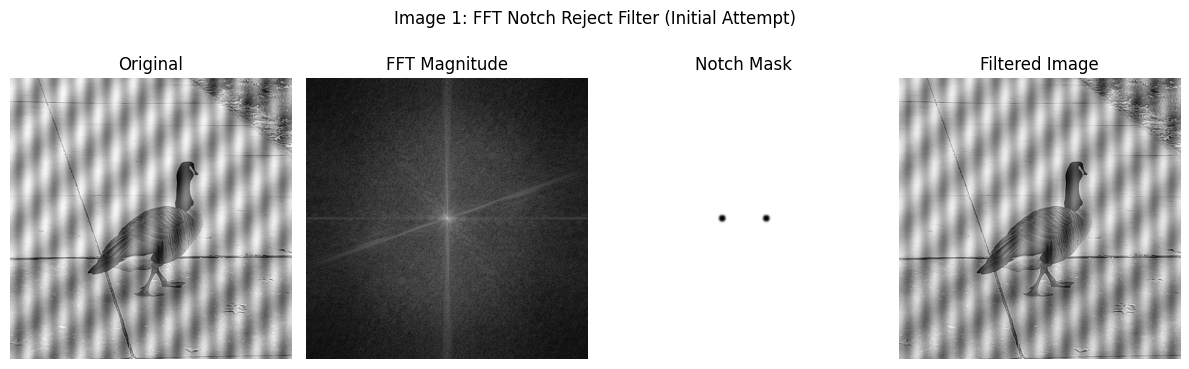

Result: Basic notch filter reduces some bands but residual moiré remains — needs a more adaptive approach.

Processing Image 1: DCT-based Adaptive Notch Filter...


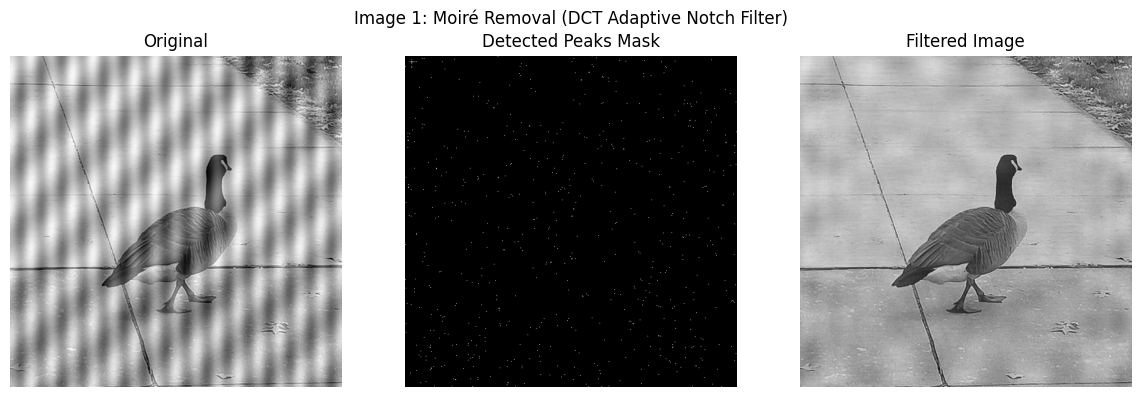

DCT-based adaptive filter completed. Output saved in: ../outputs/q4



In [8]:
#paths
IMG1_PATH = "../images/q4_1.png"
IMG2_PATH = "../images/q4_2.jpg"
OUTPUT_DIR = "../outputs/q4"
os.makedirs(OUTPUT_DIR, exist_ok=True)

#helper functions
def show_results(title, imgs, names):
    plt.figure(figsize=(12,4))
    for i, (im, name) in enumerate(zip(imgs, names)):
        plt.subplot(1, len(imgs), i+1)
        plt.imshow(im, cmap='gray' if im.ndim==2 else None)
        plt.title(name)
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

#FFT notch reject filter (first attempt)
print("Processing Image 1: FFT Notch Reject Filter")

img1 = cv2.imread(IMG1_PATH, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
rows, cols = img1.shape
crow, ccol = rows // 2, cols // 2

#FFT + magnitude spectrum
F = np.fft.fftshift(np.fft.fft2(img1))
mag = np.log1p(np.abs(F))

#building basic notch reject mask
mask = np.ones((rows, cols), np.float32)
r_notch = 6   # notch radius
offset = 40   # distance from center (empirical for vertical moiré)
centers = [(crow, ccol - offset), (crow, ccol + offset)]

Y, X = np.ogrid[:rows, :cols]
for cy, cx in centers:
    dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
    mask[dist <= r_notch] = 0

mask = cv2.GaussianBlur(mask, (9,9), 0)

#appling the notch mask
F_filtered = F * mask
img1_filtered = np.fft.ifft2(np.fft.ifftshift(F_filtered))
img1_filtered = normalize(np.abs(img1_filtered))

#mild sharpening to visualize details
restored_notch = cv2.addWeighted(img1_filtered, 1.15, cv2.GaussianBlur(img1_filtered, (5,5), 0), -0.15, 0)

cv2.imwrite(f"{OUTPUT_DIR}/q4_1_filtered_notch_attempt.png", (restored_notch*255).astype(np.uint8))

show_results("Image 1: FFT Notch Reject Filter (Initial Attempt)",
             [img1, mag, mask, restored_notch],
             ["Original", "FFT Magnitude", "Notch Mask", "Filtered Image"])

print("Result: Basic notch filter reduces some bands but residual moiré remains — needs a more adaptive approach.\n")

#dct - based adaptive notch filter 
print("Processing Image 1: DCT-based Adaptive Notch Filter...")

def dct2(a):
    return dct(dct(a.T, norm='ortho').T, norm='ortho')

def idct2(a):
    return idct(idct(a.T, norm='ortho').T, norm='ortho')

#remoces periodic/moire noise using dct peak suppression
#r: size of neighborhood for median filtering
#alpha: threshold factor for detecting peaks
def dct_adaptive_notch(img, r=2, alpha=5):
    J = dct2(img)
    aJ = np.abs(J)
    local_med = median_filter(aJ, size=(2*r+1, 2*r+1), mode='reflect')

    #detects abnormal peaks
    mask = (aJ > alpha * local_med)
    mask[:r, :r] = False  # ignore low frequencies

    #replace those with neighborhood median
    medJ = median_filter(J, size=(2*r+1, 2*r+1), mode='reflect')
    Jf = J.copy()
    Jf[mask] = medJ[mask]

    res = idct2(Jf)
    return normalize(res), normalize(mask.astype(np.float32))

#apply adaptive filter
restored_dct, mask_dct = dct_adaptive_notch(img1, r=2, alpha=5)

#mild sharpening
restored_dct_sharp = cv2.addWeighted(restored_dct, 1.1, cv2.GaussianBlur(restored_dct, (5,5), 0), -0.1, 0)

cv2.imwrite(f"{OUTPUT_DIR}/q4_1_filtered_dctnotch_final.png", (restored_dct_sharp*255).astype(np.uint8))

show_results("Image 1: Moiré Removal (DCT Adaptive Notch Filter)",
             [img1, mask_dct, restored_dct_sharp],
             ["Original", "Detected Peaks Mask", "Filtered Image"])

print(f"DCT-based adaptive filter completed. Output saved in: {OUTPUT_DIR}\n")


**2. Halftone Removal (Image 2)**  
Halftone dots were removed through **hybrid spatial filtering**:
1. Gaussian blur → to reduce high-frequency dot energy.  
2. Median filter → to eliminate small repetitive peaks.  
3. Bilateral filter → to smooth flat regions while preserving edges.  
4. Mild unsharp masking → to restore clarity.

This sequential combination successfully reconstructed a clean grayscale image with even tonal regions and clear object boundaries.


Processing Image 2: Halftone artifact removal...


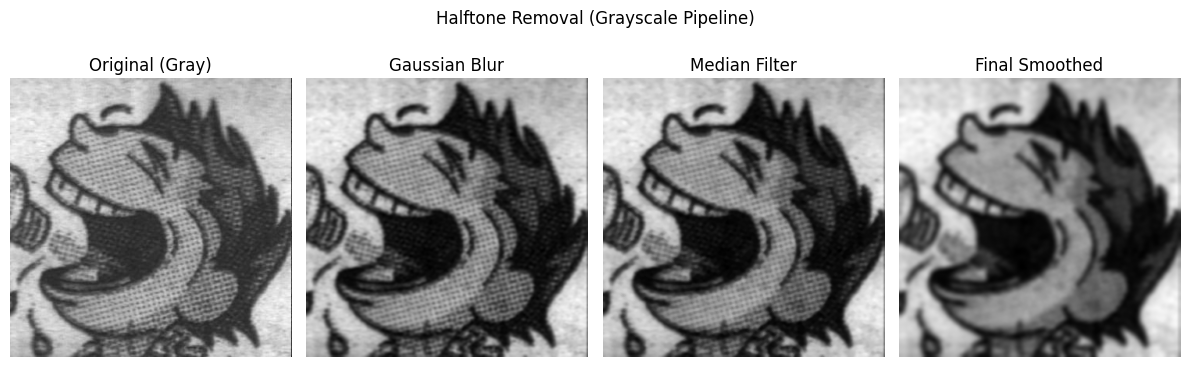

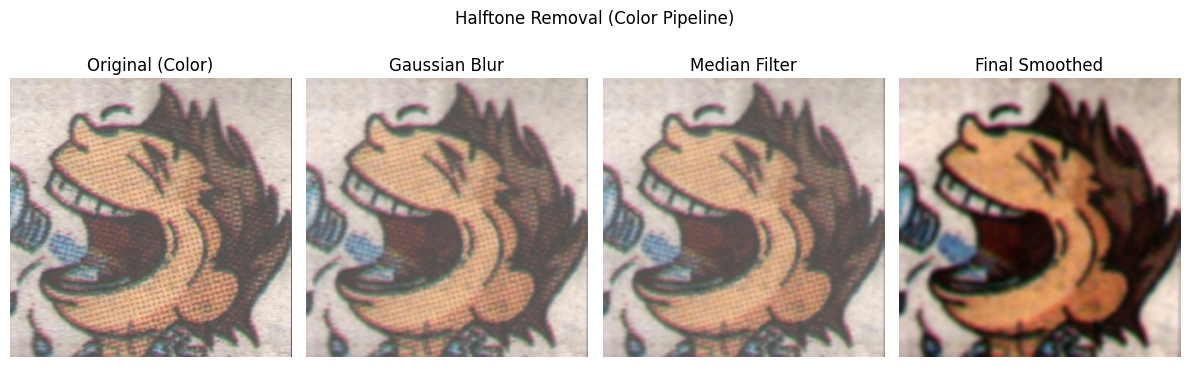

All Q4 outputs saved in: ../outputs/q4


In [9]:
print("Processing Image 2: Halftone artifact removal...")
#load image
img_color = cv2.cvtColor(cv2.imread(IMG2_PATH), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

#grayscale pipeline
blurred_g = cv2.GaussianBlur(gray, (5,5), 0)
median_g = cv2.medianBlur((blurred_g*255).astype(np.uint8), 3).astype(np.float32)/255.0
bilateral_g = cv2.bilateralFilter(median_g, 9, 75, 75)
sharp_g = cv2.addWeighted(bilateral_g, 1.2, cv2.GaussianBlur(bilateral_g, (5,5), 0), -0.2, 0)
final_gray = normalize(sharp_g)

cv2.imwrite(f"{OUTPUT_DIR}/q4_2_filtered_gray.png", (final_gray*255).astype(np.uint8))

show_results("Halftone Removal (Grayscale Pipeline)",
             [gray, blurred_g, median_g, final_gray],
             ["Original (Gray)", "Gaussian Blur", "Median Filter", "Final Smoothed"])

#color pipeline
blurred_c = cv2.GaussianBlur(img_color, (5,5), 0)

#median per channel
median_c = np.zeros_like(img_color)
for c in range(3):
    median_c[:, :, c] = cv2.medianBlur((blurred_c[:, :, c]*255).astype(np.uint8), 3).astype(np.float32)/255.0

bilateral_c = cv2.bilateralFilter(median_c, 9, 75, 75)
sharp_c = cv2.addWeighted(bilateral_c, 1.2, cv2.GaussianBlur(bilateral_c, (5,5), 0), -0.2, 0)
final_color = normalize(sharp_c)

cv2.imwrite(f"{OUTPUT_DIR}/q4_2_filtered_color.png",
            (cv2.cvtColor(final_color, cv2.COLOR_RGB2BGR)*255).astype(np.uint8))

show_results("Halftone Removal (Color Pipeline)",
             [img_color, blurred_c, median_c, final_color],
             ["Original (Color)", "Gaussian Blur", "Median Filter", "Final Smoothed"])

print(f"All Q4 outputs saved in: {OUTPUT_DIR}")


### Results

| Image | Method | Observations |
|:------|:--------|:--------------|
| Image 1 | FFT Notch Reject | Reduced some bands but left visible vertical ripples. |
| Image 1 | DCT Adaptive Notch | Clean, smooth reconstruction with minimal artifacts. |
| Image 2 | Hybrid | Halftone texture effectively removed, edges preserved. |

For Image 1:
Both filtering pipelines demonstrate the effectiveness of **analytical frequency and spatial processing**.  
While manual notch placement proved unreliable, the **DCT-adaptive technique** generalized better and avoided over-filtering.  

### Conclusion

The **DCT-based adaptive notch filter** provided a stable, artifact-free solution to periodic moiré noise, outperforming the manual FFT approach.  
The **hybrid spatial filtering** (which included ***Gaussian Blur***, ***Median Filter***, ***Bilateral Filter***, ***Mild unsharp masking***) for halftone artifacts achieved balanced smoothing and edge preservation. 

---

### References

1. Stack Overflow – *Algorithm for periodic noise removal in images using band-reject filters (notch)*  
   [https://stackoverflow.com/questions/71907248/algorithm-for-periodic-noise-removal-in-images-using-band-reject-filters-notch](https://stackoverflow.com/questions/71907248/algorithm-for-periodic-noise-removal-in-images-using-band-reject-filters-notch)

2. F. Chamizo – *Cleaning periodic noise using the Discrete Cosine Transform (DCT)*  
   Universidad Autónoma de Madrid, Digital Image Processing Notes.  
   [https://matematicas.uam.es/~fernando.chamizo/dark/d_periodic.html](https://matematicas.uam.es/~fernando.chamizo/dark/d_periodic.html)

3. Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing (4th Edition)*. Pearson Education.

---
